In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import optuna 

from sklearn.model_selection import train_test_split,StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score,roc_auc_score 


In [2]:
df=pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


eda with plotting 

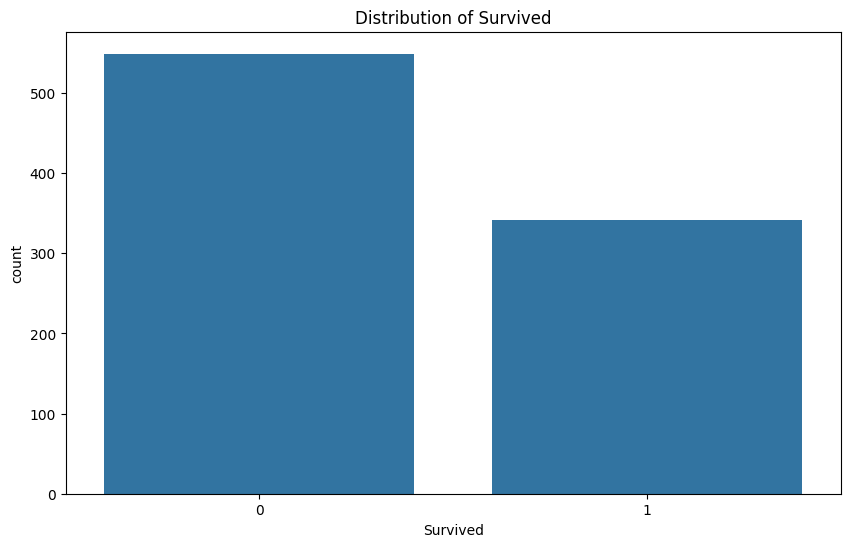

In [3]:
plt.figure(figsize=(10,6))
sns.countplot(x='Survived',data=df)
plt.title('Distribution of Survived')
plt.show()

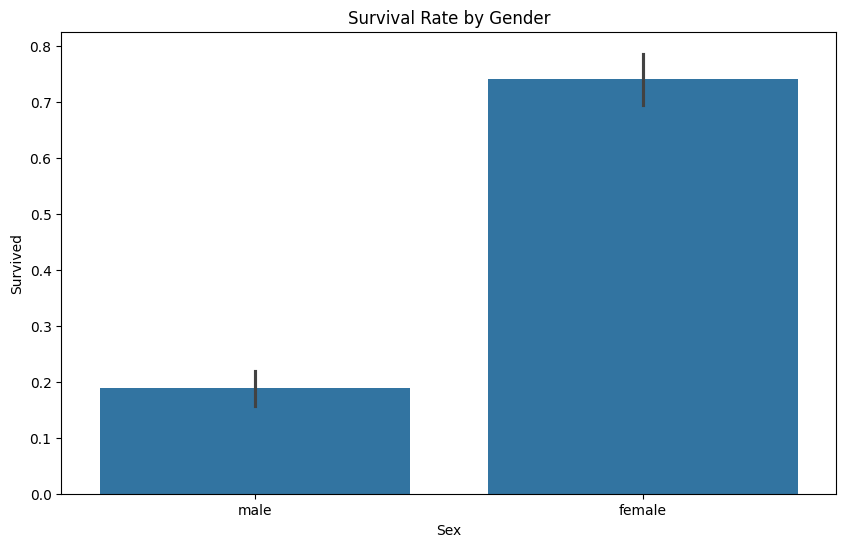

In [4]:
plt.figure(figsize=(10,6))
sns.barplot(x="Sex",y="Survived",data=df)
plt.title('Survival Rate by Gender')
plt.show()

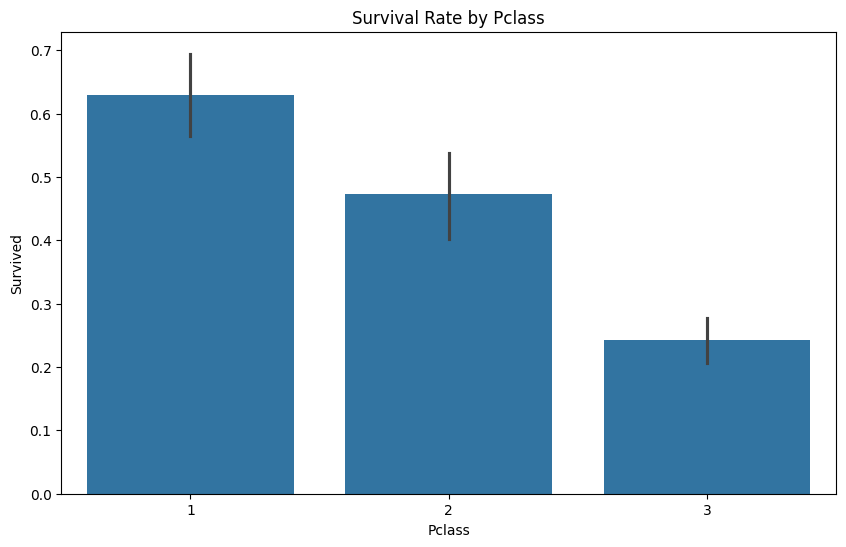

In [5]:
plt.figure(figsize=(10,6))
sns.barplot(x='Pclass',y='Survived',data=df)
plt.title('Survival Rate by Pclass')
plt.show()

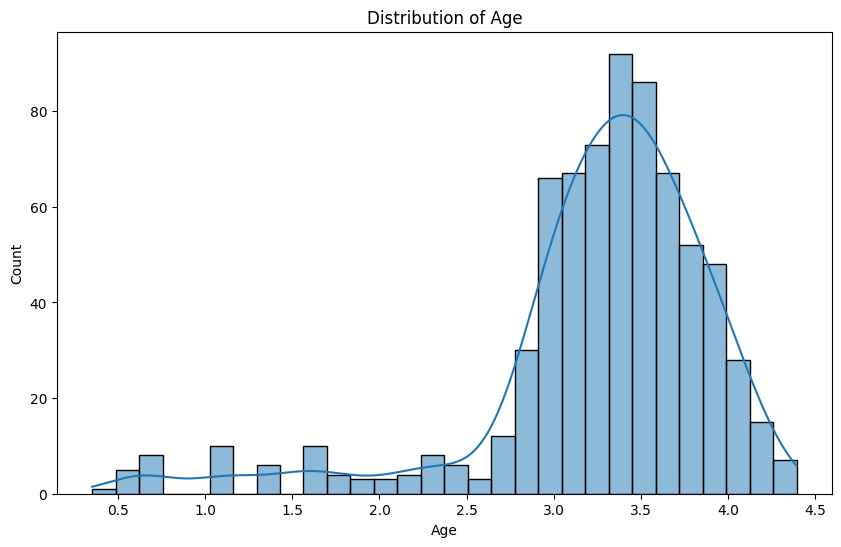

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['Age']),bins=30,kde=True)
plt.title('Distribution of Age')
plt.show()

max preprocessing and feature engineering 

In [7]:
df['Title']=df["Name"].str.extract(' ([A-Za-z]+)\.',expand=False)
df['Title'].value_counts()
df.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/var/folders/79/qf4s258d1979pqm6v_z63bmc0000gn/T/ipykernel_1533/3781505064.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title']=df["Name"].str.extract(' ([A-Za-z]+)\.',expand=False)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [8]:
rare_titles=['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
df['Title']=df['Title'].replace(rare_titles,'Rare')
df['Title']=df['Title'].replace(['Mlle','Ms'],'Miss')
df['Title']=df['Title'].replace('Mme','Mrs')
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

family features

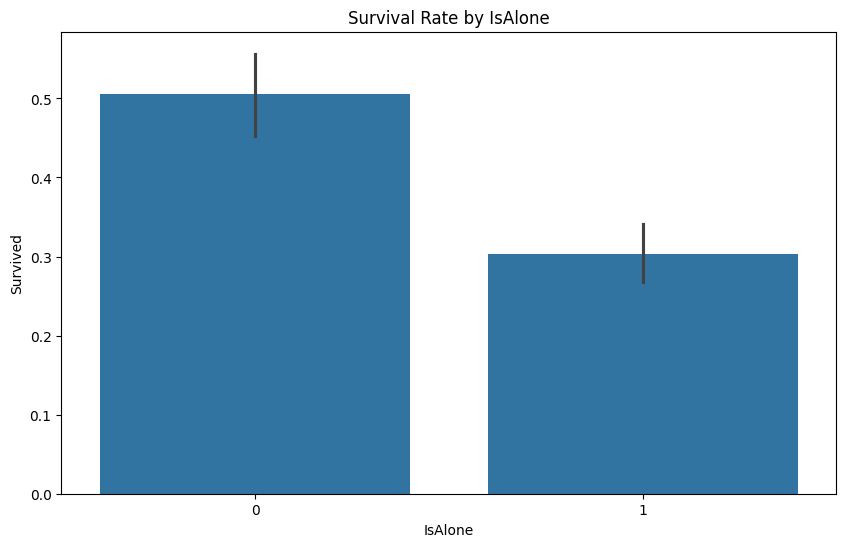

In [9]:
df['FamilySize']=df['SibSp']+df['Parch']+1
df['IsAlone']=df['FamilySize'].apply(lambda x: 1 if x==1 else 0)
plt.figure(figsize=(10,6))
sns.barplot(x='IsAlone',y='Survived',data=df)
plt.title('Survival Rate by IsAlone')
plt.show()

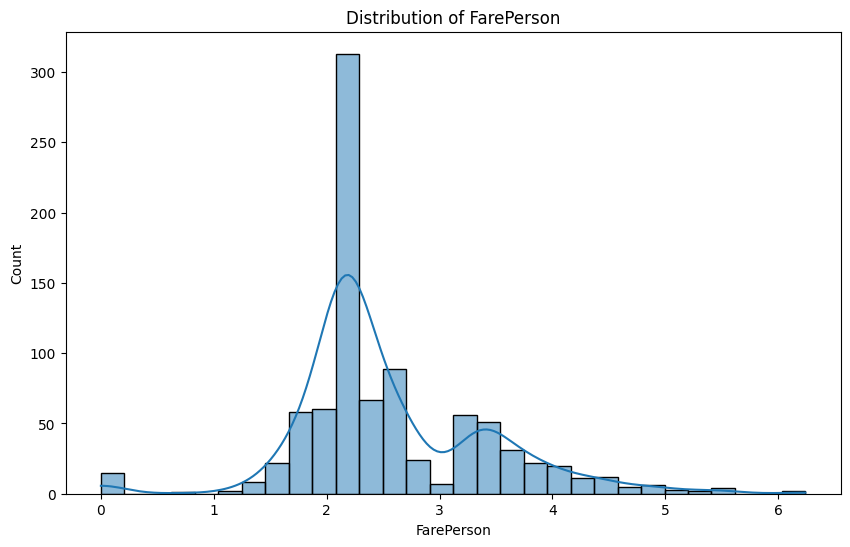

In [10]:
df['FarePerson']=df['Fare']/(df['FamilySize'])
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['FarePerson']),bins=30,kde=True)
plt.title('Distribution of FarePerson')
plt.show()

In [11]:
df["LogFare"]=np.log1p(df['Fare'])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FarePerson,LogFare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,3.62500,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,35.64165,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,7.92500,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,26.55000,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,8.05000,2.202765


In [12]:
df['AgeGroup']=df.groupby("Title")['Age'].transform(lambda x: x.fillna(x.median()))
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FarePerson,LogFare,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,3.62500,2.110213,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,35.64165,4.280593,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,7.92500,2.188856,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,26.55000,3.990834,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,8.05000,2.202765,35.0


In [14]:
df['AgeGroup']=pd.cut(df['Age'],bins=[0,12,18,35,60,80],labels=['Child','Teenager','Adult','MiddleAged','Senior'])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FarePerson,LogFare,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,3.62500,2.110213,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,35.64165,4.280593,MiddleAged
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,7.92500,2.188856,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,26.55000,3.990834,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,8.05000,2.202765,Adult


In [16]:
df["cabin"]=df['Cabin'].fillna("U")
df["Deck"]=df["cabin"].str[0]
df["Deck"].value_counts()

Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [17]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])


In [18]:
df=df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,FarePerson,LogFare,AgeGroup,cabin,Deck,Embraked
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,3.62500,2.110213,Adult,U,U,S
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,35.64165,4.280593,MiddleAged,C85,C,C
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,7.92500,2.188856,Adult,U,U,S
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,26.55000,3.990834,Adult,C123,C,S
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,8.05000,2.202765,Adult,U,U,S


final dataset preparation 

In [19]:
x=df.drop('Survived',axis=1)
y=df['Survived']
cat_cols=x.select_dtypes(include=['object','category']).columns.tolist()
cat_idx=[x.columns.get_loc(col) for col in cat_cols]
cat_cols

['Sex', 'Embarked', 'Title', 'AgeGroup', 'cabin', 'Deck', 'Embraked']

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [25]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_auc,cv_acc=[],[]

cat_cols_train=x_train.select_dtypes(include=['object','category']).columns.tolist()
cat_idx_train=[x_train.columns.get_loc(col) for col in cat_cols_train]

for fold,(tr_idx,val_idx) in enumerate(skf.split(x_train,y_train)):
    x_tr,x_val=x_train.iloc[tr_idx].copy(),x_train.iloc[val_idx].copy()
    y_tr,y_val=y_train.iloc[tr_idx],y_train.iloc[val_idx]

    # CatBoost requires categorical features to be string/int (no raw NaN floats).
    x_tr[cat_cols_train]=x_tr[cat_cols_train].astype('object').where(x_tr[cat_cols_train].notna(),'Missing').astype(str)
    x_val[cat_cols_train]=x_val[cat_cols_train].astype('object').where(x_val[cat_cols_train].notna(),'Missing').astype(str)

    model=CatBoostClassifier(iterations=3000,learning_rate=0.02,depth=7,l2_leaf_reg=3,random_strength=1,loss_function='Logloss',verbose=0)
    model.fit(
        x_tr,y_tr,
        cat_features=cat_idx_train,
        eval_set=[(x_val,y_val)],
        early_stopping_rounds=100,
        verbose=100
    )
    val_pred=model.predict(x_val)
    val_proba=model.predict_proba(x_val)[:,1]
    cv_auc.append(roc_auc_score(y_val,val_proba))

    cv_acc.append(accuracy_score(y_val,val_pred))
    print(f'Fold {fold+1} - AUC: {cv_auc[-1]:.4f}, Accuracy: {cv_acc[-1]:.4f}')
print(f'CV AUC: {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')
print(f'CV Accuracy: {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}')


0:	learn: 0.6836392	test: 0.6842456	best: 0.6842456 (0)	total: 55.5ms	remaining: 2m 46s
100:	learn: 0.3527484	test: 0.3997496	best: 0.3997496 (100)	total: 318ms	remaining: 9.14s
200:	learn: 0.2966853	test: 0.3895315	best: 0.3895315 (200)	total: 596ms	remaining: 8.3s
300:	learn: 0.2598877	test: 0.3870709	best: 0.3865448 (291)	total: 859ms	remaining: 7.7s
400:	learn: 0.2266520	test: 0.3844219	best: 0.3839885 (374)	total: 1.17s	remaining: 7.61s
500:	learn: 0.1988728	test: 0.3815374	best: 0.3814840 (498)	total: 1.46s	remaining: 7.26s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.3814840413
bestIteration = 498

Shrink model to first 499 iterations.
Fold 1 - AUC: 0.8792, Accuracy: 0.8392
0:	learn: 0.6813932	test: 0.6825140	best: 0.6825140 (0)	total: 2.33ms	remaining: 6.98s
100:	learn: 0.3400690	test: 0.4437682	best: 0.4437682 (100)	total: 269ms	remaining: 7.73s
200:	learn: 0.2869889	test: 0.4381578	best: 0.4381578 (200)	total: 587ms	remaining: 8.17s
300:	learn: 0.25126

In [28]:
x_train_final=x_train.copy()
cat_cols_final=x_train_final.select_dtypes(include=['object','category']).columns.tolist()
cat_idx_final=[x_train_final.columns.get_loc(col) for col in cat_cols_final]
x_train_final[cat_cols_final]=x_train_final[cat_cols_final].astype('object').where(x_train_final[cat_cols_final].notna(),'Missing').astype(str)

final_model=CatBoostClassifier(iterations=3000,learning_rate=0.02,depth=7,l2_leaf_reg=3,random_strength=1,loss_function='Logloss',verbose=0,eval_metric='AUC')
final_model.fit(
    x_train_final,y_train,cat_features=cat_idx_final
)


In [30]:
x_test_final=x_test.copy()
cat_cols_model=[x_test_final.columns[i] for i in final_model.get_cat_feature_indices()]
x_test_final[cat_cols_model]=x_test_final[cat_cols_model].astype('object').where(x_test_final[cat_cols_model].notna(),'Missing').astype(str)

test_pred=final_model.predict(x_test_final)
test_proba=final_model.predict_proba(x_test_final)[:,1]
print(f"Final test AUC: {roc_auc_score(y_test,test_proba):.4f}, Accuracy: {accuracy_score(y_test,test_pred):.4f}")


Final test AUC: 0.8336, Accuracy: 0.8101
